# NBA Draft Analysis

I've been playing basketball my whole life — high school, Air Force base teams, and rec league now. One of the things that's always fascinated me is how teams evaluate talent. Every year fans debate whether teams drafted the right guy. This project looks at 20 years of NBA draft data from Kaggle (1990–2021) to ask a simple question: **does where you get drafted actually determine whether you'll have a successful NBA career?**

### What defines a successful NBA Career?

It's hard to measure success in the NBA because of how much the game has evolved. With the ever changing landscape, I believe that rookie contracts are the right benchmark here. First round picks get 4-year deals, second round picks get 2-year deals. So success means a player outlasted their initial contract:

- **First round picks (1-30):** 4+ seasons
- **Second round picks (31-60):** 3+ seasons


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 1. Load and Query the Data

> Add blockquote



In [9]:
# Load the dataset
df = pd.read_csv('draft-data-20-years.csv', index_col=0)

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (1868, 25)

First 5 rows:


,Rk,Pk,Tm,Player,College,Yrs,G,TOTMP,TOTPTS,TOTTRB,...,WS/48,BPM,VORP,DraftYr,MPG,PPG,RPG,APG,playerurl,DraftYear
recordid,,,,,,,,,,,,,,,,,,,,,
1,1,1,BRK,Derrick Coleman,Syracuse,15.0,781.0,25903.0,12884.0,7232.0,...,0.119,1.4,22.3,1990,33.2,16.5,9.3,2.5,https://www.sports-reference.com/cbb/players/d...,1990
2,2,2,OKC,Gary Payton,Oregon State,17.0,1335.0,47117.0,21813.0,5269.0,...,0.148,3.3,62.5,1990,35.3,16.3,3.9,6.7,https://www.sports-reference.com/cbb/players/g...,1990
3,3,3,DEN,Mahmoud Abdul-Rauf,LSU,9.0,586.0,15628.0,8553.0,1087.0,...,0.077,-0.8,4.5,1990,26.7,14.6,1.9,3.5,https://www.sports-reference.com/cbb/players/m...,1990
4,4,4,ORL,Dennis Scott,Georgia Tech,10.0,629.0,17983.0,8094.0,1774.0,...,0.089,0.2,9.9,1990,28.6,12.9,2.8,2.1,https://www.sports-reference.com/cbb/players/d...,1990
5,5,5,CHA,Kendall Gill,Illinois,15.0,966.0,29481.0,12914.0,4002.0,...,0.078,0.1,15.8,1990,30.5,13.4,4.1,3.0,https://www.sports-reference.com/cbb/players/k...,1990


In [11]:
# This will show how many players, how many years and how long their career was/is
print('Total players:', len(df))
print('Players who never played an NBA game:', df['Yrs'].isna().sum())
print('\nYears in NBA distribution:')
print(df['Yrs'].describe())

Total players: 1868
Players who never played an NBA game: 247

Years in NBA distribution:
count    1621.000000
mean        6.305367
std         4.640924
min         1.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        22.000000
Name: Yrs, dtype: float64


## 2. Define Success Based on Rookie Contract Length

In [12]:
# Players with NaN in Yrs never played — treat as 0
df['Yrs'] = df['Yrs'].fillna(0)

# Define success based on pick round
# First round (1-30): must play 4+ seasons (full rookie deal)
# Second round (31-60): must play 3+ seasons (beyond their shorter deal)
def define_success(row):
    if row['Pk'] <= 30:
        return 1 if row['Yrs'] >= 4 else 0
    else:
        return 1 if row['Yrs'] >= 3 else 0

df['Success'] = df.apply(define_success, axis=1)

print('Successful players:', df['Success'].sum())
print('Unsuccessful players:', (df['Success'] == 0).sum())
print('\nOverall success rate: {:.1f}%'.format(df['Success'].mean() * 100))

Successful players: 1091
Unsuccessful players: 777

Overall success rate: 58.4%


In [13]:
# Create pick ranges
def pick_range(pk):
    if pk <= 14:
        return 'Lottery (1-14)'
    elif pk <= 30:
        return 'Late First (15-30)'
    else:
        return 'Second Round (31-60)'

df['PickRange'] = df['Pk'].apply(pick_range)

print('Pick range breakdown:')
print(df['PickRange'].value_counts())

Pick range breakdown:
PickRange
Second Round (31-60)    910
Late First (15-30)      510
Lottery (1-14)          448
Name: count, dtype: int64


## 3. Does Draft Position Actually Matter?

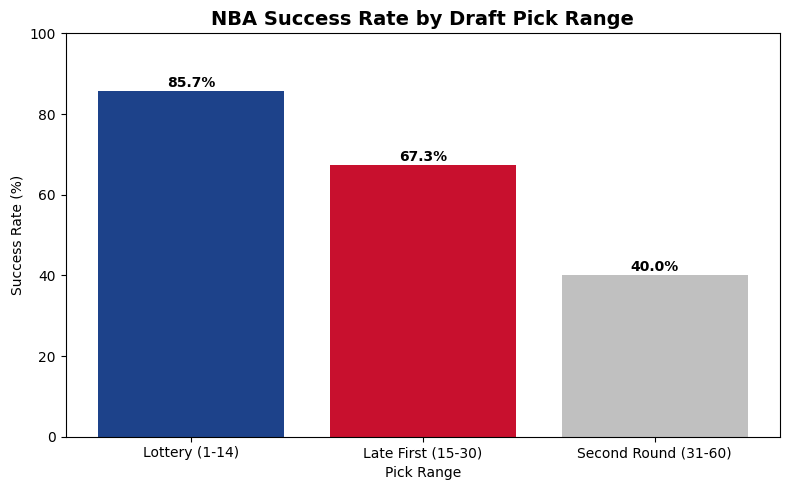

In [15]:
# Success rate by pick range
# Group players by pick range and calculate the success rate for each group.
# Multiply by 100 to get a percentage, then reindex to control the display order.
#The bar chart shows how success rate changes across lottery, late first round, and second round picks
# The loop at the end adds the percentage label on top of each bar

success_by_range = df.groupby('PickRange')['Success'].mean() * 100
success_by_range = success_by_range.reindex(['Lottery (1-14)', 'Late First (15-30)', 'Second Round (31-60)'])

plt.figure(figsize=(8, 5))
bars = plt.bar(success_by_range.index, success_by_range.values, color=['#1d428a', '#c8102e', '#c0c0c0'])
plt.title('NBA Success Rate by Draft Pick Range', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
plt.xlabel('Pick Range')
plt.ylim(0, 100)

for bar, val in zip(bars, success_by_range.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

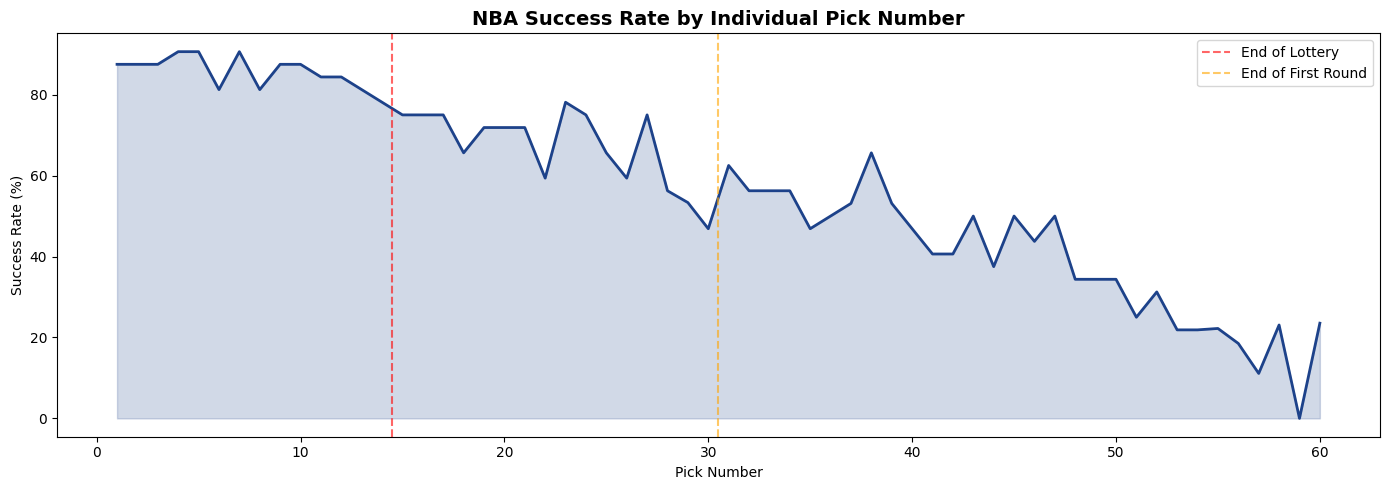

In [16]:
# Instead of grouping by range, this looks at every individual pick number (1 through 60).
# The line chart makes it easier to see the gradual drop in success rate as picks get later. The vertical shows where the first and second start and stop

success_by_pick = df.groupby('Pk')['Success'].mean() * 100

plt.figure(figsize=(14, 5))
plt.plot(success_by_pick.index, success_by_pick.values, color='#1d428a', linewidth=2)
plt.axvline(x=14.5, color='red', linestyle='--', alpha=0.6, label='End of Lottery')
plt.axvline(x=30.5, color='orange', linestyle='--', alpha=0.6, label='End of First Round')
plt.fill_between(success_by_pick.index, success_by_pick.values, alpha=0.2, color='#1d428a')
plt.title('NBA Success Rate by Individual Pick Number', fontsize=14, fontweight='bold')
plt.xlabel('Pick Number')
plt.ylabel('Success Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

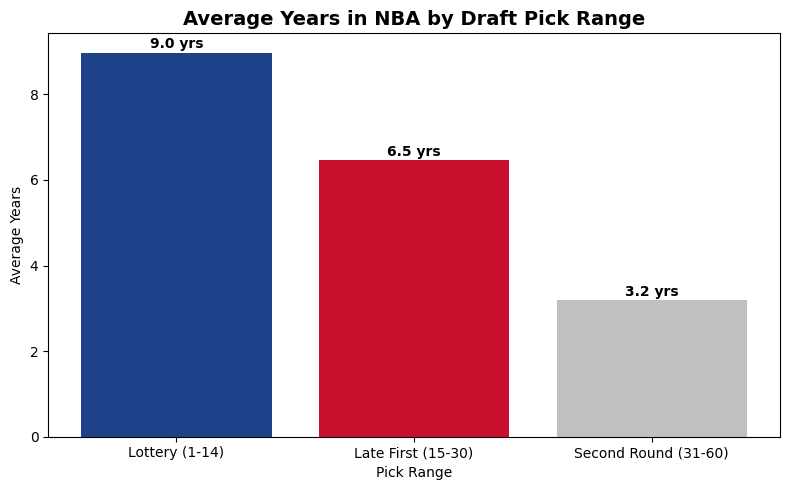

In [17]:
# Average years in NBA by pick range
avg_yrs = df.groupby('PickRange')['Yrs'].mean()
avg_yrs = avg_yrs.reindex(['Lottery (1-14)', 'Late First (15-30)', 'Second Round (31-60)'])

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_yrs.index, avg_yrs.values, color=['#1d428a', '#c8102e', '#c0c0c0'])
plt.title('Average Years in NBA by Draft Pick Range', fontsize=14, fontweight='bold')
plt.ylabel('Average Years')
plt.xlabel('Pick Range')

for bar, val in zip(bars, avg_yrs.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f} yrs', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Can we Predict success?

In [19]:
# We're going to try and see if we can predict success by using a random forrest model.This should work because it helps prevents overfitting to our training data
# The reasoning we are trying to accomplish is a majoprity decision rather than one distinct outcome.
# Pick number and Draft year should suffice.

# Features and target
features = ['Pk', 'DraftYear']
X = df[features]
y = df['Success']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Model Accuracy: {:.1f}%'.format(accuracy_score(y_test, y_pred) * 100))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Model Accuracy: 70.6%

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       160
           1       0.74      0.75      0.75       214

    accuracy                           0.71       374
   macro avg       0.70      0.70      0.70       374
weighted avg       0.71      0.71      0.71       374



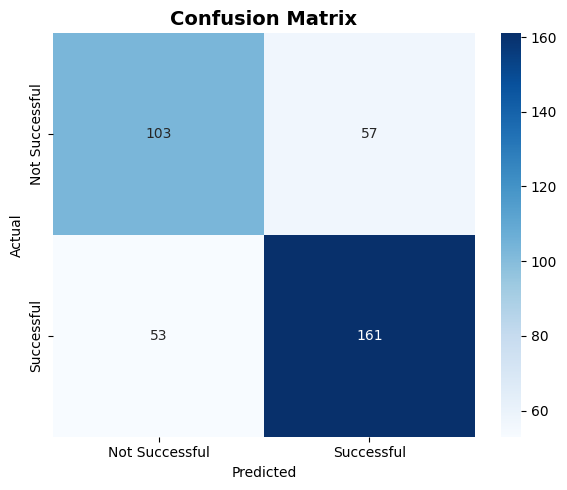

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

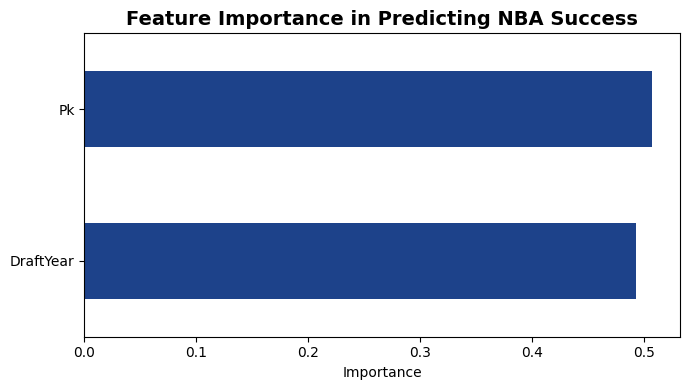

In [21]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='#1d428a')
plt.title('Feature Importance in Predicting NBA Success', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. Key Takeaways

- Lottery picks succeed at a much higher rate however, it's not guaranteed. Teams still miss at the top of the draft.
- Second round picks are a big gamble. Success rates drop significantly after pick 30, which makes sense given the shorter, non-guaranteed contracts.
- Draft position alone is a decent but imperfect predictor, however there's clear signal in the pick number but plenty of misses in every range, which is exactly why teams invest in scouting and analytics.
- The bigger question this raises: what separates the hits from the misses within each range? That's where college stats, physical measurements, and player tracking data come in — and where analytics departments earn their value.
---
**Author:** Brandon Diaz-Lopez  
**M.S. Data Analytics — UCF 2024**  
[Portfolio](https://brandondiazlopez.github.io/BrandonDiaz-Lopez2.github.io/) | [LinkedIn](https://www.linkedin.com/in/brandon-diaz-lopez-)